# Paper-style linear graph-identification sanity check

This notebook checks whether the **linear graph-learning baseline** behaves like the paper setup:

- linear consensus dynamics;
- Barabási-Albert graph with `N=15`, `m=2`, directed by pruning;
- one passive observation interval before the first control decision;
- 5 controlled campaigns;
- `h = 2.0`, `s = 0.5`, `omega = 1.0`, `u_bar = 0.2`;
- row-stochastic zero-diagonal learned adjacency;
- paper-style Euler one-step prediction model.

The main recovery test is **Laplacian + linear identifier**. The same linear identifier is also run on nonlinear dynamics as a deliberate mismatch sanity check.

Primary paper metrics:

- `delta_hat`: final consensus error of the learned-linear allocation;
- `delta_star`: final consensus error of the true-A centrality allocation;
- `suboptimality = delta_hat - delta_star`;
- `max_v_L1`: largest centrality-vector error encountered across campaigns.

For Laplacian dynamics, the true-A centrality policy is the oracle from the paper. For nonlinear dynamics, it should be read only as a **true-A centrality baseline**, not a proof of optimality.

In [8]:
from __future__ import annotations

import contextlib
import io
import math
import os
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Find repo root from the notebook location or current working directory.
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "opinion_dynamics").exists():
            return p
    raise RuntimeError("Could not find repo root containing opinion_dynamics/. Run this notebook from the repo or set REPO_ROOT manually.")

REPO_ROOT = find_repo_root()
print("REPO_ROOT:", REPO_ROOT)

import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control

REPO_ROOT: d:\Work\repos\RL\unknown_graph_networks


## Configuration

The default grid is intentionally small enough for a sanity check. Increase the seed lists only after the first run looks reasonable.

`BETA_PER_CAMPAIGN` is the per-campaign available budget passed into the repo's continuous water-filling helper. With `u_bar=0.2`, `BETA_PER_CAMPAIGN=1.0` can fully control at most five nodes per campaign.

In [9]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using DEVICE:", DEVICE)

STUDY_DATE = "2026_06_30"
STUDY_NAME = "paper_linear_baseline_sanity"
RESULTS_DIR = REPO_ROOT / "opinion_dynamics" / "experiments" / "results" / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_DIR)

# Main recovery test is laplacian. The nonlinear dynamics are mismatch checks using the same linear identifier.
DYNAMICS_LIST = [
    "laplacian",
    "coca",
    "hegselmannkrause",
]

TOPOLOGY_SEEDS = [3, 4, 5]
INITIAL_PERMUTATION_SEEDS = [0, 1, 2]

# Paper-style environment settings.
N_AGENTS = 15
PAPER_H = 2.0          # inter-campaign time h
PAPER_S = 0.5          # observation sampling period s
OMEGA = 1.0            # desired opinion
U_BAR = 0.2            # per-agent max control
PASSIVE_OBSERVATION_INTERVALS = 1
NUM_CONTROLLED_CAMPAIGNS = 5
BETA_PER_CAMPAIGN = 1.0

# Paper-style graph learner settings.
LR = 1e-3
L2_LAMBDA = 0.0
FIT_MAX_STEPS = 50_000
FIT_MAE_STOP = 1e-3
FIT_BATCH_SIZE = 64
FIT_CHECK_EVERY = 200
SUPPRESS_FIT_LOGS = True

# Reproducibility.
INITIAL_STATE_SEED_BASE = 920_000
TRAIN_SEED_BASE = 421_000

# Storage toggles.
STORE_FINAL_NODE_TABLES = False
KEEP_TRIAL_ARTIFACTS = False

config_summary = {
    "study_name": STUDY_NAME,
    "dynamics": DYNAMICS_LIST,
    "topology_seeds": TOPOLOGY_SEEDS,
    "initial_permutation_seeds": INITIAL_PERMUTATION_SEEDS,
    "n_trials_expected": len(DYNAMICS_LIST) * len(TOPOLOGY_SEEDS) * len(INITIAL_PERMUTATION_SEEDS),
    "N": N_AGENTS,
    "passive_observation_intervals": PASSIVE_OBSERVATION_INTERVALS,
    "num_controlled_campaigns": NUM_CONTROLLED_CAMPAIGNS,
    "h": PAPER_H,
    "s": PAPER_S,
    "omega": OMEGA,
    "u_bar": U_BAR,
    "beta_per_campaign": BETA_PER_CAMPAIGN,
    "fit_max_steps": FIT_MAX_STEPS,
    "fit_mae_stop": FIT_MAE_STOP,
    "fit_batch_size": FIT_BATCH_SIZE,
}
config_summary

Using DEVICE: cpu
Results dir: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_06_30_paper_linear_baseline_sanity


{'study_name': 'paper_linear_baseline_sanity',
 'dynamics': ['laplacian', 'coca', 'hegselmannkrause'],
 'topology_seeds': [3, 4, 5],
 'initial_permutation_seeds': [0, 1, 2],
 'n_trials_expected': 27,
 'N': 15,
 'passive_observation_intervals': 1,
 'num_controlled_campaigns': 5,
 'h': 2.0,
 's': 0.5,
 'omega': 1.0,
 'u_bar': 0.2,
 'beta_per_campaign': 1.0,
 'fit_max_steps': 50000,
 'fit_mae_stop': 0.001,
 'fit_batch_size': 64}

## Paper-style helpers

The identifier below intentionally uses the paper's Euler one-step model:

```text
x_next_i = x_i + s * sum_j A_ij * (x_j - x_i)
```

This differs from the current repo's `identify.py`, which uses the exact matrix exponential for the linear consensus step. For this sanity check, the Euler model is the desired paper-style baseline.

In [10]:
def set_global_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def as_vector_max_u(max_u: Any, n: int) -> np.ndarray:
    u = np.asarray(max_u, dtype=float)
    if u.ndim == 0:
        return np.full(n, float(u), dtype=float)
    u = u.reshape(-1).astype(float)
    if u.shape != (n,):
        raise ValueError(f"max_u must be scalar or shape ({n},), got {u.shape}")
    return u


def sanitize_centrality(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    v = np.asarray(v, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if v.sum() < 0:
        v = -v
    v = np.maximum(v, 0.0)
    s = float(v.sum())
    if s <= eps:
        v = np.abs(v)
        s = float(v.sum())
    if s <= eps:
        return np.full_like(v, 1.0 / len(v))
    return v / s


def centrality_from_A(A: np.ndarray) -> np.ndarray:
    return sanitize_centrality(compute_eigenvector_centrality(compute_laplacian(np.asarray(A, dtype=float))))


def make_paper_initial_opinions(n: int, permutation_seed: int) -> np.ndarray:
    rng = np.random.default_rng(INITIAL_STATE_SEED_BASE + int(permutation_seed))
    x = np.linspace(0.0, 1.0, int(n), dtype=float)
    return rng.permutation(x)


def set_initial_state(env: Any, x0: np.ndarray) -> None:
    x0 = np.asarray(x0, dtype=float).reshape(-1)
    if hasattr(env, "initial_opinions"):
        try:
            env.initial_opinions = x0.copy()
        except Exception:
            pass
    env.opinions = x0.copy()
    if hasattr(env, "state"):
        try:
            env.state = x0.copy()
        except Exception:
            pass


def clone_env_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    h: float = PAPER_H,
    s: float = PAPER_S,
    omega: float = OMEGA,
    u_bar: float = U_BAR,
    terminate_when_converged: bool = False,
) -> Any:
    n = int(env_template.num_agents)
    kwargs = dict(
        connectivity_matrix=np.array(env_template.connectivity_matrix, copy=True),
        num_agents=n,
        max_u=np.full(n, float(u_bar), dtype=float),
        desired_opinion=float(omega),
        t_campaign=float(h),
        t_s=float(s),
        dynamics_model=str(dynamics_model if dynamics_model is not None else getattr(env_template, "dynamics_model", "laplacian")),
        control_resistance=np.array(getattr(env_template, "control_resistance", np.zeros(n)), copy=True),
        max_steps=int(getattr(env_template, "max_steps", 10_000)),
        opinion_end_tolerance=float(getattr(env_template, "opinion_end_tolerance", 0.01)),
        control_beta=float(getattr(env_template, "control_beta", 0.4)),
        normalize_reward=bool(getattr(env_template, "normalize_reward", False)),
        terminal_reward=float(getattr(env_template, "terminal_reward", 0.0)),
        terminate_when_converged=bool(terminate_when_converged),
        seed=int(getattr(env_template, "seed", 0)) if getattr(env_template, "seed", None) is not None else None,
    )
    optional_attrs = [
        "fj_lambda", "fj_prejudice", "hk_epsilon", "hk_include_self",
        "nonlinear_beta", "repulsion_epsilon", "repulsion_strength",
    ]
    for attr in optional_attrs:
        if hasattr(env_template, attr):
            kwargs[attr] = getattr(env_template, attr)

    EnvCls = env_template.__class__
    try:
        return EnvCls(**kwargs)
    except TypeError:
        # Some env versions may not accept all optional dynamics kwargs.
        for attr in optional_attrs:
            kwargs.pop(attr, None)
        return EnvCls(**kwargs)


def make_base_env(topology_seed: int, dynamics_model: str) -> Any:
    factory = EnvironmentFactory()
    env = factory.get_randomized_env(seed=int(topology_seed), dynamics_model=str(dynamics_model))
    return clone_env_from_template(
        env,
        dynamics_model=dynamics_model,
        h=PAPER_H,
        s=PAPER_S,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )


def pairs_from_intermediate(intermediate_states: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    inter = np.asarray(intermediate_states, dtype=float)
    return inter[:-1], inter[1:]


def uniform_budget_action(max_u: np.ndarray, budget: float) -> np.ndarray:
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    n = max_u.size
    u = np.zeros(n, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    active = np.ones(n, dtype=bool)
    while remaining > 1e-12 and active.any():
        idxs = np.where(active)[0]
        share = remaining / len(idxs)
        progressed = False
        for i in idxs:
            add = min(share, float(max_u[i] - u[i]))
            if add > 0:
                u[i] += add
                remaining -= add
                progressed = True
            if u[i] >= max_u[i] - 1e-12:
                active[i] = False
        if not progressed:
            break
    return u

In [11]:
class PaperLinearGraphIdentifier(nn.Module):
    """Paper-style row-stochastic zero-diagonal adjacency learner using Euler one-step dynamics."""

    def __init__(self, N: int, s: float, l2_lambda: float = 0.0, zero_diag: bool = True):
        super().__init__()
        self.N = int(N)
        self.s = float(s)
        self.l2_lambda = float(l2_lambda)
        self.zero_diag = bool(zero_diag)
        self.Theta = nn.Parameter(torch.zeros(self.N, self.N))
        nn.init.kaiming_uniform_(self.Theta, a=0.0)
        self.register_buffer("_diag_mask", 1.0 - torch.eye(self.N))
        self.last_fit_info = {}

    def A_hat(self) -> torch.Tensor:
        A = F.softmax(self.Theta, dim=1)
        if self.zero_diag:
            A = A * self._diag_mask
            rs = A.sum(dim=1, keepdim=True)
            rs = torch.where(rs > 0, rs, torch.ones_like(rs))
            A = A / rs
        return A

    def predict_next(self, x: torch.Tensor) -> torch.Tensor:
        A = self.A_hat()
        # For each row i: x_i + s * sum_j A_ij * (x_j - x_i).
        neighbor_avg = x @ A.T
        return x + self.s * (neighbor_avg - x)

    def loss(self, x: torch.Tensor, x_next: torch.Tensor):
        pred = self.predict_next(x)
        mse = F.mse_loss(pred, x_next)
        l2 = (self.Theta ** 2).sum()
        return mse + self.l2_lambda * l2, {"mse": mse.detach(), "l2": l2.detach()}


def train_paper_linear_identifier(
    model: PaperLinearGraphIdentifier,
    data_x: np.ndarray,
    data_x_next: np.ndarray,
    *,
    lr: float = LR,
    batch_size: int = FIT_BATCH_SIZE,
    max_steps: int = FIT_MAX_STEPS,
    mae_stop: float = FIT_MAE_STOP,
    fit_check_every: int = FIT_CHECK_EVERY,
    device: str = DEVICE,
    suppress_logs: bool = SUPPRESS_FIT_LOGS,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    model.to(device)
    X = torch.tensor(np.asarray(data_x, dtype=np.float32), dtype=torch.float32, device=device)
    Y = torch.tensor(np.asarray(data_x_next, dtype=np.float32), dtype=torch.float32, device=device)
    n = int(X.shape[0])
    if n == 0:
        raise ValueError("No training pairs provided.")

    opt = torch.optim.Adam(model.parameters(), lr=float(lr))
    stop_reason = "max_steps"
    last_mae = float("nan")
    t0 = time.perf_counter()

    for step in range(int(max_steps)):
        idx = torch.randint(0, n, (min(int(batch_size), n),), device=device)
        loss, _ = model.loss(X[idx], Y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % int(fit_check_every) == 0 or step == int(max_steps) - 1:
            with torch.no_grad():
                yhat = model.predict_next(X)
                mae = float((yhat - Y).abs().mean().item())
                last_mae = mae
            if (not suppress_logs) and (step % 2000 == 0 or mae <= mae_stop):
                print(f"[paper-linear-fit] step={step} mae={mae:.5g} n_pairs={n}")
            if mae <= float(mae_stop):
                stop_reason = "mae_stop"
                break

    fit_time = time.perf_counter() - t0
    with torch.no_grad():
        A = model.A_hat().detach().cpu().numpy()
        yhat = model.predict_next(X)
        final_mae = float((yhat - Y).abs().mean().item())
        identity_mae = float((X - Y).abs().mean().item())

    info = {
        "steps_run": int(step + 1),
        "stop_reason": stop_reason,
        "train_mae": final_mae,
        "identity_mae": identity_mae,
        "model_over_identity": final_mae / (identity_mae + 1e-12),
        "n_pairs": n,
        "fit_time_sec": float(fit_time),
    }
    model.last_fit_info = info
    return A, info

## Rollout routines

The learned policy follows the paper-style loop:

1. observe one passive interval with zero control;
2. fit the linear graph model;
3. apply learned-centrality water filling;
4. observe the next interval;
5. refit with the accumulated buffer.

No epsilon exploration is used here.

In [12]:
def step_env_collect(env: Any, action: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, np.ndarray]:
    x_next, reward, done, truncated, info = env.step(np.asarray(action, dtype=float))
    inter = info.get("intermediate_states", None)
    if inter is None:
        raise RuntimeError("env.step did not return info['intermediate_states']")
    return np.asarray(x_next, dtype=float), float(reward), bool(done), bool(truncated), np.asarray(inter, dtype=float)


def rollout_fixed_policy(
    env_template: Any,
    x0: np.ndarray,
    *,
    policy_name: str,
    v_policy: Optional[np.ndarray] = None,
    beta_per_campaign: float = BETA_PER_CAMPAIGN,
    passive_intervals: int = PASSIVE_OBSERVATION_INTERVALS,
    num_controlled_campaigns: int = NUM_CONTROLLED_CAMPAIGNS,
) -> Dict[str, Any]:
    env = clone_env_from_template(env_template, terminate_when_converged=False)
    env.reset()
    set_initial_state(env, x0)

    states = [np.asarray(x0, dtype=float).copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []

    # Passive observation windows before first control decision.
    for _ in range(int(passive_intervals)):
        u = np.zeros(env.num_agents, dtype=float)
        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))

    for _ in range(int(num_controlled_campaigns)):
        if policy_name == "no_control":
            u = np.zeros(env.num_agents, dtype=float)
        elif policy_name == "uniform":
            u = uniform_budget_action(as_vector_max_u(env.max_u, env.num_agents), beta_per_campaign)
        elif policy_name == "true_A_centrality":
            if v_policy is None:
                raise ValueError("v_policy is required for true_A_centrality")
            u, _ = centrality_based_continuous_control(env, beta_per_campaign, v=v_policy)
        else:
            raise ValueError(f"Unknown policy_name={policy_name}")

        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))

    return {
        "policy": policy_name,
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
    }


def rollout_learned_paper_linear(
    env_template: Any,
    x0: np.ndarray,
    *,
    topology_seed: int,
    initial_seed: int,
    dynamics_model: str,
    beta_per_campaign: float = BETA_PER_CAMPAIGN,
    passive_intervals: int = PASSIVE_OBSERVATION_INTERVALS,
    num_controlled_campaigns: int = NUM_CONTROLLED_CAMPAIGNS,
) -> Dict[str, Any]:
    env = clone_env_from_template(env_template, terminate_when_converged=False)
    env.reset()
    set_initial_state(env, x0)

    N = int(env.num_agents)
    train_seed = TRAIN_SEED_BASE + 10_000 * int(topology_seed) + 100 * int(initial_seed) + abs(hash(dynamics_model)) % 97
    set_global_seed(train_seed)

    states = [np.asarray(x0, dtype=float).copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []
    A_hats = []
    v_hats = []
    fit_infos = []
    buf_x, buf_y = [], []

    # Passive observation windows before first learned control decision.
    for _ in range(int(passive_intervals)):
        u = np.zeros(N, dtype=float)
        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))
        Xp, Yp = pairs_from_intermediate(inter)
        buf_x.append(Xp)
        buf_y.append(Yp)

    model = PaperLinearGraphIdentifier(N=N, s=float(env.t_s), l2_lambda=L2_LAMBDA, zero_diag=True)

    for k in range(int(num_controlled_campaigns)):
        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)
        A_hat, fit_info = train_paper_linear_identifier(
            model,
            X,
            Y,
            lr=LR,
            batch_size=FIT_BATCH_SIZE,
            max_steps=FIT_MAX_STEPS,
            mae_stop=FIT_MAE_STOP,
            fit_check_every=FIT_CHECK_EVERY,
            device=DEVICE,
            suppress_logs=SUPPRESS_FIT_LOGS,
        )
        v_hat = centrality_from_A(A_hat)
        A_hats.append(np.asarray(A_hat, dtype=float).copy())
        v_hats.append(v_hat.copy())
        fit_infos.append(dict(fit_info, campaign_index=int(k)))

        u, _ = centrality_based_continuous_control(env, beta_per_campaign, v=v_hat)
        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))
        Xp, Yp = pairs_from_intermediate(inter)
        buf_x.append(Xp)
        buf_y.append(Yp)

    return {
        "policy": "learned_linear",
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "A_hats": A_hats,
        "v_hats": v_hats,
        "fit_infos": fit_infos,
    }

In [13]:
def final_consensus_error(states: np.ndarray, v_true: np.ndarray, omega: float = OMEGA) -> float:
    final_state = np.asarray(states, dtype=float)[-1]
    consensus_value = float(np.asarray(v_true, dtype=float).reshape(-1) @ final_state)
    return abs(float(omega) - consensus_value)


def trajectory_rows(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    policy: str,
    rollout: Dict[str, Any],
    v_true: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []
    states = np.asarray(rollout["states"], dtype=float)
    times = np.asarray(rollout["boundary_times"], dtype=float)
    for idx, (t, x) in enumerate(zip(times, states)):
        rows.append({
            "dynamics": dynamics,
            "topology_seed": int(topology_seed),
            "initial_seed": int(initial_seed),
            "trial_id": f"{dynamics}|topo={topology_seed}|init={initial_seed}",
            "policy": policy,
            "boundary_index": int(idx),
            "time": float(t),
            "mean_opinion": float(np.mean(x)),
            "min_opinion": float(np.min(x)),
            "max_opinion": float(np.max(x)),
            "consensus_value": float(np.asarray(v_true).reshape(-1) @ np.asarray(x).reshape(-1)),
        })
    return rows


def summarize_trial(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    A_true: np.ndarray,
    v_true: np.ndarray,
    learned: Dict[str, Any],
    true_A: Dict[str, Any],
    uniform: Dict[str, Any],
    no_control: Dict[str, Any],
) -> Dict[str, Any]:
    A_hats = learned["A_hats"]
    v_hats = learned["v_hats"]
    v_errs = [float(np.sum(np.abs(np.asarray(vh) - v_true))) for vh in v_hats]
    A_final = np.asarray(A_hats[-1], dtype=float)
    v_final = np.asarray(v_hats[-1], dtype=float)

    delta_hat = final_consensus_error(learned["states"], v_true)
    delta_star = final_consensus_error(true_A["states"], v_true)
    delta_uniform = final_consensus_error(uniform["states"], v_true)
    delta_noc = final_consensus_error(no_control["states"], v_true)

    learned_mean_end = float(np.mean(learned["states"][-1]))
    true_A_mean_end = float(np.mean(true_A["states"][-1]))
    uniform_mean_end = float(np.mean(uniform["states"][-1]))
    noc_mean_end = float(np.mean(no_control["states"][-1]))

    last_fit = learned["fit_infos"][-1]

    return {
        "dynamics": dynamics,
        "topology_seed": int(topology_seed),
        "initial_seed": int(initial_seed),
        "trial_id": f"{dynamics}|topo={topology_seed}|init={initial_seed}",
        "delta_hat": float(delta_hat),
        "delta_star": float(delta_star),
        "delta_uniform": float(delta_uniform),
        "delta_nocontrol": float(delta_noc),
        "suboptimality": float(delta_hat - delta_star),
        "learned_minus_uniform_delta": float(delta_hat - delta_uniform),
        "learned_minus_nocontrol_delta": float(delta_hat - delta_noc),
        "mean_learned_end": learned_mean_end,
        "mean_true_A_end": true_A_mean_end,
        "mean_uniform_end": uniform_mean_end,
        "mean_nocontrol_end": noc_mean_end,
        "learned_minus_uniform_mean_end": learned_mean_end - uniform_mean_end,
        "learned_minus_true_A_mean_end": learned_mean_end - true_A_mean_end,
        "learned_minus_nocontrol_mean_end": learned_mean_end - noc_mean_end,
        "max_v_L1": float(max(v_errs)),
        "final_v_L1": float(np.sum(np.abs(v_final - v_true))),
        "A_MAE_final": float(np.mean(np.abs(A_final - A_true))),
        "A_Fro_final": float(np.linalg.norm(A_final - A_true, ord="fro")),
        "final_train_mae": float(last_fit["train_mae"]),
        "final_identity_mae": float(last_fit["identity_mae"]),
        "final_model_over_identity": float(last_fit["model_over_identity"]),
        "final_n_pairs": int(last_fit["n_pairs"]),
        "total_fit_time_sec": float(sum(info["fit_time_sec"] for info in learned["fit_infos"])),
    }

## Run the study

This cell may take time with `FIT_MAX_STEPS=50_000`. For a fast smoke test, reduce `TOPOLOGY_SEEDS`, `INITIAL_PERMUTATION_SEEDS`, or `FIT_MAX_STEPS` in the config cell.

In [14]:
trial_rows = []
traj_rows = []
final_node_rows = []
artifacts = {} if KEEP_TRIAL_ARTIFACTS else None

run_t0 = time.perf_counter()

for dynamics in DYNAMICS_LIST:
    for topology_seed in TOPOLOGY_SEEDS:
        base_env = make_base_env(topology_seed, dynamics)
        A_true = np.asarray(base_env.connectivity_matrix, dtype=float)
        v_true = centrality_from_A(A_true)

        for initial_seed in INITIAL_PERMUTATION_SEEDS:
            trial_id = f"{dynamics}|topo={topology_seed}|init={initial_seed}"
            print(f"Running {trial_id} ...")
            x0 = make_paper_initial_opinions(base_env.num_agents, initial_seed)

            learned = rollout_learned_paper_linear(
                base_env,
                x0,
                topology_seed=topology_seed,
                initial_seed=initial_seed,
                dynamics_model=dynamics,
            )
            true_A = rollout_fixed_policy(
                base_env,
                x0,
                policy_name="true_A_centrality",
                v_policy=v_true,
            )
            uniform = rollout_fixed_policy(base_env, x0, policy_name="uniform")
            no_control = rollout_fixed_policy(base_env, x0, policy_name="no_control")

            trial_rows.append(summarize_trial(
                dynamics=dynamics,
                topology_seed=topology_seed,
                initial_seed=initial_seed,
                A_true=A_true,
                v_true=v_true,
                learned=learned,
                true_A=true_A,
                uniform=uniform,
                no_control=no_control,
            ))

            for policy, ro in [
                ("learned_linear", learned),
                ("true_A_centrality", true_A),
                ("uniform", uniform),
                ("no_control", no_control),
            ]:
                traj_rows.extend(trajectory_rows(
                    dynamics=dynamics,
                    topology_seed=topology_seed,
                    initial_seed=initial_seed,
                    policy=policy,
                    rollout=ro,
                    v_true=v_true,
                ))

            if STORE_FINAL_NODE_TABLES:
                for policy, ro in [
                    ("learned_linear", learned),
                    ("true_A_centrality", true_A),
                    ("uniform", uniform),
                    ("no_control", no_control),
                ]:
                    xf = np.asarray(ro["states"][-1], dtype=float)
                    for node, value in enumerate(xf):
                        final_node_rows.append({
                            "trial_id": trial_id,
                            "dynamics": dynamics,
                            "topology_seed": int(topology_seed),
                            "initial_seed": int(initial_seed),
                            "policy": policy,
                            "node": int(node),
                            "final_opinion": float(value),
                        })

            if KEEP_TRIAL_ARTIFACTS:
                artifacts[trial_id] = {
                    "A_true": A_true,
                    "v_true": v_true,
                    "x0": x0,
                    "learned": learned,
                    "true_A": true_A,
                    "uniform": uniform,
                    "no_control": no_control,
                }

elapsed = time.perf_counter() - run_t0
print(f"Done in {elapsed:.1f}s")

trial_df = pd.DataFrame(trial_rows)
trajectory_df = pd.DataFrame(traj_rows)
final_node_df = pd.DataFrame(final_node_rows)

trial_df.to_csv(RESULTS_DIR / "trial_summary.csv", index=False)
trajectory_df.to_csv(RESULTS_DIR / "trajectory_boundaries.csv", index=False)
if STORE_FINAL_NODE_TABLES:
    final_node_df.to_csv(RESULTS_DIR / "final_node_table.csv", index=False)

print("Saved:", RESULTS_DIR)
display(trial_df.head())

Running laplacian|topo=3|init=0 ...
Running laplacian|topo=3|init=1 ...
Running laplacian|topo=3|init=2 ...
Running laplacian|topo=4|init=0 ...
Running laplacian|topo=4|init=1 ...
Running laplacian|topo=4|init=2 ...
Running laplacian|topo=5|init=0 ...
Running laplacian|topo=5|init=1 ...
Running laplacian|topo=5|init=2 ...
Running coca|topo=3|init=0 ...
Running coca|topo=3|init=1 ...
Running coca|topo=3|init=2 ...
Running coca|topo=4|init=0 ...
Running coca|topo=4|init=1 ...
Running coca|topo=4|init=2 ...
Running coca|topo=5|init=0 ...
Running coca|topo=5|init=1 ...
Running coca|topo=5|init=2 ...
Running hegselmannkrause|topo=3|init=0 ...
Running hegselmannkrause|topo=3|init=1 ...
Running hegselmannkrause|topo=3|init=2 ...
Running hegselmannkrause|topo=4|init=0 ...
Running hegselmannkrause|topo=4|init=1 ...
Running hegselmannkrause|topo=4|init=2 ...
Running hegselmannkrause|topo=5|init=0 ...
Running hegselmannkrause|topo=5|init=1 ...
Running hegselmannkrause|topo=5|init=2 ...
Done in 29

,dynamics,topology_seed,initial_seed,trial_id,delta_hat,delta_star,delta_uniform,delta_nocontrol,suboptimality,learned_minus_uniform_delta,...,learned_minus_nocontrol_mean_end,max_v_L1,final_v_L1,A_MAE_final,A_Fro_final,final_train_mae,final_identity_mae,final_model_over_identity,final_n_pairs,total_fit_time_sec
0,laplacian,3,0,laplacian|topo=3|init=0,0.295640,0.255699,0.334256,0.471950,0.039941,-0.038616,...,0.175712,0.391990,0.277072,0.069535,1.792317,0.001000,0.019088,0.052378,20,18.694790
1,laplacian,3,1,laplacian|topo=3|init=1,0.295846,0.248080,0.328187,0.463380,0.047766,-0.032341,...,0.166477,0.569482,0.363676,0.075039,1.857843,0.000997,0.018402,0.054156,20,10.975435
2,laplacian,3,2,laplacian|topo=3|init=2,0.282883,0.241204,0.315813,0.445909,0.041679,-0.032930,...,0.161285,0.482159,0.368323,0.060588,1.595412,0.000999,0.019091,0.052346,20,12.634264
3,laplacian,4,0,laplacian|topo=4|init=0,0.232927,0.187721,0.287208,0.405521,0.045206,-0.054282,...,0.169681,0.851711,0.631526,0.077835,2.145528,0.000986,0.019923,0.049494,20,7.750558
4,laplacian,4,1,laplacian|topo=4|init=1,0.195735,0.165496,0.254625,0.359516,0.030239,-0.058891,...,0.163294,0.904584,0.735307,0.069462,1.985696,0.000954,0.021063,0.045296,20,11.572975


## Summary tables

For Laplacian dynamics, `suboptimality = delta_hat - delta_star` is the paper-style measure: how much worse the learned-linear allocation is than the true-A centrality allocation.

For nonlinear dynamics, the same table is useful as a mismatch diagnostic, but `true_A_centrality` should not be read as the true nonlinear optimum.

In [15]:
def mean_sem(x: pd.Series) -> pd.Series:
    x = pd.Series(x).dropna()
    n = len(x)
    return pd.Series({
        "mean": float(x.mean()) if n else np.nan,
        "sem": float(x.std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
        "n": int(n),
    })

summary_cols = [
    "delta_hat", "delta_star", "suboptimality",
    "learned_minus_uniform_delta",
    "mean_learned_end", "mean_true_A_end", "mean_uniform_end", "mean_nocontrol_end",
    "learned_minus_uniform_mean_end", "learned_minus_true_A_mean_end",
    "max_v_L1", "final_v_L1", "A_MAE_final", "final_model_over_identity", "final_n_pairs",
]

summary = (
    trial_df
    .groupby("dynamics")[summary_cols]
    .agg(["mean", "std", "count"])
    .round(5)
)
summary

delta_hat                delta_star                 \
                      mean      std count       mean      std count   
dynamics                                                              
coca               0.23562  0.09031     9    0.18612  0.07677     9   
hegselmannkrause   0.30785  0.04425     9    0.24329  0.04611     9   
laplacian          0.26516  0.03986     9    0.23212  0.04421     9   

                 suboptimality                learned_minus_uniform_delta  \
                          mean      std count                        mean   
dynamics                                                                    
coca                   0.04950  0.02467     9                    -0.03055   
hegselmannkrause       0.06456  0.04045     9                    -0.02915   
laplacian              0.03304  0.01518     9                    -0.06427   

                  ... final_v_L1 A_MAE_final                 \
                  ...      count        mean      std count   
dynamics          ...                                         
coca              ...          9     0.10324  0.01301     9   
hegselmannkrause  ...          9     0.10217  0.01051     9   
laplacian         ...          9     0.06518  0.00940     9   

                 final_model_over_identity                final_n_pairs       \
                                      mean      std count          mean  std   
dynamics                                                                       
coca                               1.36424  0.36392     9          20.0  0.0   
hegselmannkrause                   1.66399  0.63684     9          20.0  0.0   
laplacian                          0.05507  0.01020     9          20.0  0.0   

                        
                 count  
dynamics                
coca                 9  
hegselmannkrause     9  
laplacian            9  

[3 rows x 45 columns]

In [16]:
compact = (
    trial_df
    .groupby("dynamics")
    .agg(
        n_trials=("trial_id", "count"),
        delta_hat=("delta_hat", "mean"),
        delta_star=("delta_star", "mean"),
        suboptimality=("suboptimality", "mean"),
        learned_minus_uniform_delta=("learned_minus_uniform_delta", "mean"),
        mean_learned_end=("mean_learned_end", "mean"),
        mean_true_A_end=("mean_true_A_end", "mean"),
        mean_uniform_end=("mean_uniform_end", "mean"),
        mean_nocontrol_end=("mean_nocontrol_end", "mean"),
        learned_minus_uniform_mean_end=("learned_minus_uniform_mean_end", "mean"),
        win_rate_vs_uniform_mean=("learned_minus_uniform_mean_end", lambda s: float((s > 0).mean())),
        max_v_L1=("max_v_L1", "mean"),
        final_model_over_identity=("final_model_over_identity", "mean"),
        final_n_pairs=("final_n_pairs", "mean"),
    )
    .reset_index()
)
compact.round(5)

,dynamics,n_trials,delta_hat,delta_star,suboptimality,learned_minus_uniform_delta,mean_learned_end,mean_true_A_end,mean_uniform_end,mean_nocontrol_end,learned_minus_uniform_mean_end,win_rate_vs_uniform_mean,max_v_L1,final_model_over_identity,final_n_pairs
0,coca,9,0.23562,0.18612,0.04950,-0.03055,0.75378,0.78371,0.72897,0.55798,0.02481,0.88889,0.98504,1.36424,20.0
1,hegselmannkrause,9,0.30785,0.24329,0.06456,-0.02915,0.67656,0.70711,0.64182,0.48857,0.03475,0.88889,1.26497,1.66399,20.0
2,laplacian,9,0.26516,0.23212,0.03304,-0.06427,0.73239,0.76357,0.67095,0.53541,0.06144,1.00000,0.64411,0.05507,20.0


## Main trajectories

Primary visual check: average opinion over time, averaged over topology and initial-state seeds.

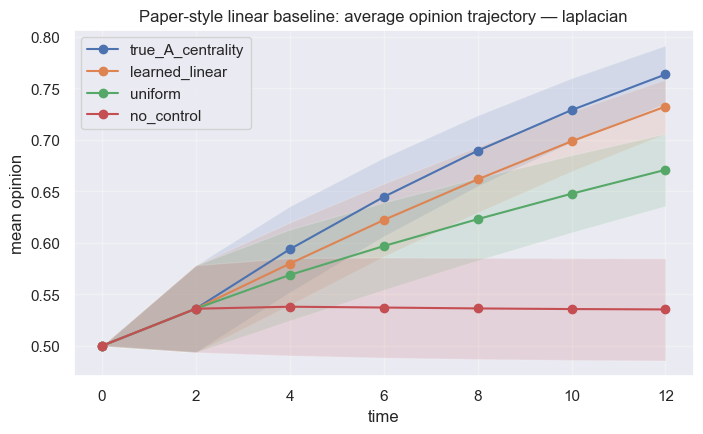

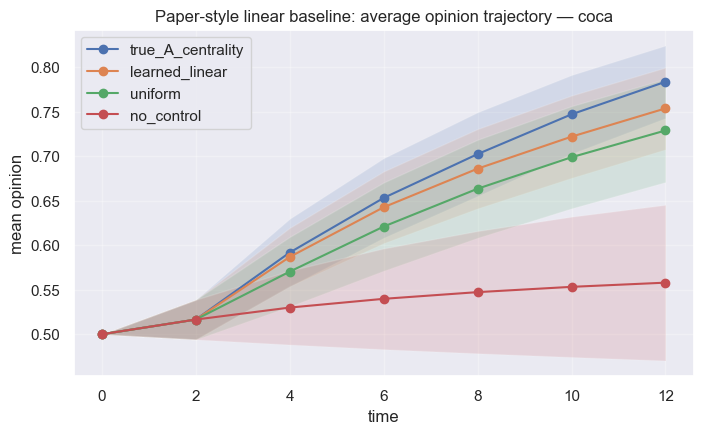

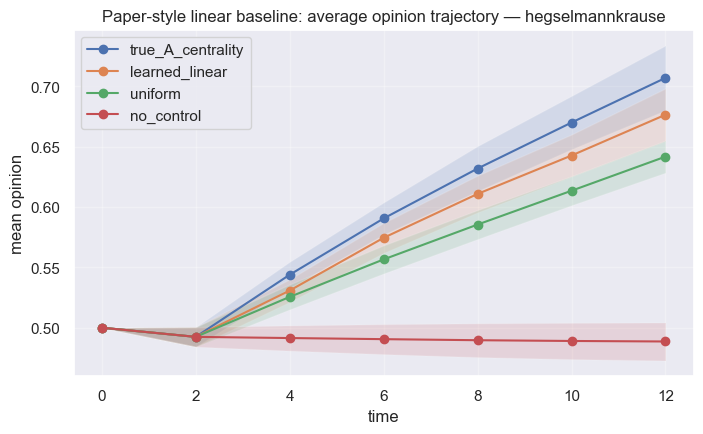

In [17]:
def plot_mean_trajectories(metric: str = "mean_opinion"):
    policies = ["true_A_centrality", "learned_linear", "uniform", "no_control"]
    for dynamics in DYNAMICS_LIST:
        df = trajectory_df[(trajectory_df["dynamics"] == dynamics) & (trajectory_df["policy"].isin(policies))].copy()
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for policy in policies:
            sub = df[df["policy"] == policy]
            grouped = sub.groupby("time")[metric]
            mean = grouped.mean()
            count = grouped.count()
            sem = grouped.std(ddof=1) / np.sqrt(count.clip(lower=1))
            sem = sem.fillna(0.0)
            x = mean.index.to_numpy(dtype=float)
            y = mean.to_numpy(dtype=float)
            e = sem.to_numpy(dtype=float)
            ax.plot(x, y, marker="o", label=policy)
            ax.fill_between(x, y - 1.96 * e, y + 1.96 * e, alpha=0.15)
        ax.set_title(f"Paper-style linear baseline: average opinion trajectory — {dynamics}")
        ax.set_xlabel("time")
        ax.set_ylabel(metric.replace("_", " "))
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
        plt.show()

plot_mean_trajectories("mean_opinion")

## Paper diagnostic: suboptimality vs centrality error

The paper's main empirical relationship is that suboptimality tracks centrality-vector approximation error. This plot is most meaningful for Laplacian dynamics.

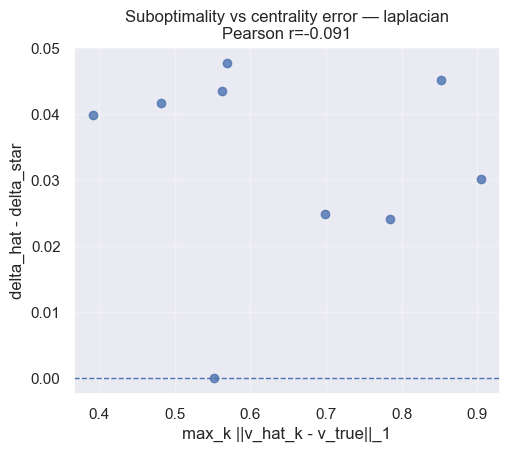

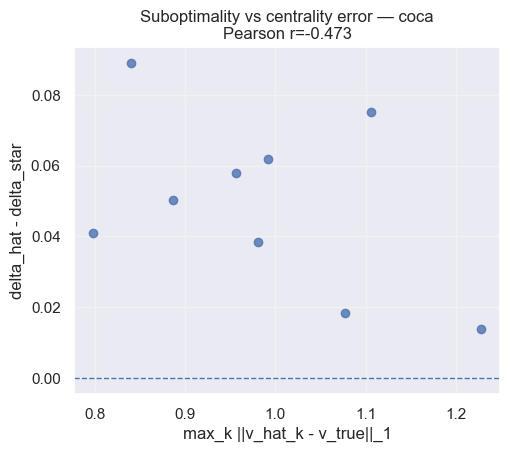

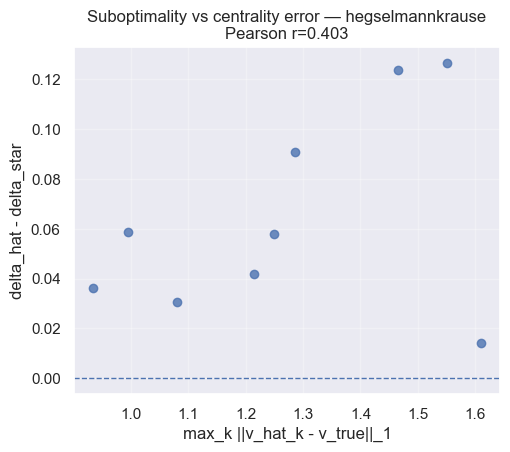

In [18]:
for dynamics in DYNAMICS_LIST:
    sub = trial_df[trial_df["dynamics"] == dynamics]
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.scatter(sub["max_v_L1"], sub["suboptimality"], alpha=0.8)
    if len(sub) >= 2:
        corr = sub[["max_v_L1", "suboptimality"]].corr().iloc[0, 1]
    else:
        corr = np.nan
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_title(f"Suboptimality vs centrality error — {dynamics}\nPearson r={corr:.3f}")
    ax.set_xlabel("max_k ||v_hat_k - v_true||_1")
    ax.set_ylabel("delta_hat - delta_star")
    ax.grid(True, alpha=0.3)
    plt.show()

## Selected-trial detail

Use this to inspect one trial in the same spirit as the paper's Fig. 1.

Selected trial: laplacian|topo=3|init=0


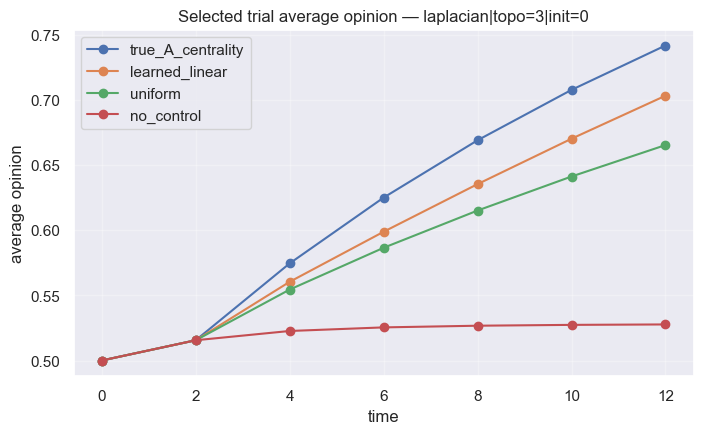

,dynamics,topology_seed,initial_seed,trial_id,delta_hat,delta_star,delta_uniform,delta_nocontrol,suboptimality,learned_minus_uniform_delta,...,learned_minus_nocontrol_mean_end,max_v_L1,final_v_L1,A_MAE_final,A_Fro_final,final_train_mae,final_identity_mae,final_model_over_identity,final_n_pairs,total_fit_time_sec
0,laplacian,3,0,laplacian|topo=3|init=0,0.29564,0.2557,0.33426,0.47195,0.03994,-0.03862,...,0.17571,0.39199,0.27707,0.06953,1.79232,0.001,0.01909,0.05238,20,18.69479


In [19]:
SELECT_DYNAMICS = "laplacian"
SELECT_TOPOLOGY_SEED = TOPOLOGY_SEEDS[0]
SELECT_INITIAL_SEED = INITIAL_PERMUTATION_SEEDS[0]

sel_id = f"{SELECT_DYNAMICS}|topo={SELECT_TOPOLOGY_SEED}|init={SELECT_INITIAL_SEED}"
print("Selected trial:", sel_id)

sel_traj = trajectory_df[trajectory_df["trial_id"] == sel_id]
fig, ax = plt.subplots(figsize=(8, 4.5))
for policy in ["true_A_centrality", "learned_linear", "uniform", "no_control"]:
    sub = sel_traj[sel_traj["policy"] == policy]
    ax.plot(sub["time"], sub["mean_opinion"], marker="o", label=policy)
ax.set_title(f"Selected trial average opinion — {sel_id}")
ax.set_xlabel("time")
ax.set_ylabel("average opinion")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

trial_df[trial_df["trial_id"] == sel_id].round(5)

In [20]:
# Optional: per-node final opinions for a selected trial, computed on demand to avoid storing misleading node-id aggregates.
def selected_trial_final_node_table(dynamics: str, topology_seed: int, initial_seed: int) -> pd.DataFrame:
    base_env = make_base_env(topology_seed, dynamics)
    A_true = np.asarray(base_env.connectivity_matrix, dtype=float)
    v_true = centrality_from_A(A_true)
    x0 = make_paper_initial_opinions(base_env.num_agents, initial_seed)
    learned = rollout_learned_paper_linear(
        base_env,
        x0,
        topology_seed=topology_seed,
        initial_seed=initial_seed,
        dynamics_model=dynamics,
    )
    true_A = rollout_fixed_policy(base_env, x0, policy_name="true_A_centrality", v_policy=v_true)
    uniform = rollout_fixed_policy(base_env, x0, policy_name="uniform")
    no_control = rollout_fixed_policy(base_env, x0, policy_name="no_control")
    rows = []
    for policy, ro in [
        ("true_A_centrality", true_A),
        ("learned_linear", learned),
        ("uniform", uniform),
        ("no_control", no_control),
    ]:
        xf = np.asarray(ro["states"][-1], dtype=float)
        for node, value in enumerate(xf):
            rows.append({"policy": policy, "node": int(node), "final_opinion": float(value)})
    return pd.DataFrame(rows)

# Uncomment if needed. This reruns one selected trial.
# node_df = selected_trial_final_node_table(SELECT_DYNAMICS, SELECT_TOPOLOGY_SEED, SELECT_INITIAL_SEED)
# display(node_df.pivot(index="node", columns="policy", values="final_opinion").round(4))

## Quick interpretation guide

For the Laplacian recovery check, look for:

1. `suboptimality` close to the paper scale;
2. positive/strong relation between `max_v_L1` and `suboptimality`;
3. learned-linear trajectory close to `true_A_centrality` and clearly above `no_control`;
4. `final_model_over_identity < 1`, preferably much smaller.

If Laplacian recovery is poor while one-step prediction is good, the likely bottleneck is centrality/ranking recovery rather than dynamics prediction.

For COCA/HK, bad performance is expected because the identifier is deliberately linear while the environment dynamics are nonlinear.